Notebook para fazer visualizações e comparações entre distribuições CPRI e Poisson.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, errno
import sys
from math import sqrt

#Settings
PRED_ALG = 'mlp'
BASE_DIR = 'test_poissonPG_IPACT_pred_{}'.format(PRED_ALG)
NUMBER_OF_OLTs = 1
NUMBER_OF_ONUs = 20
DISTANCE = 20 #Distance in kilometers
TRAFFIC = "poisson"
DBA_ALG = "ipact_pred"

IPACT_Pred_delay_medio = {}
ipact_basic_delay_medio = {}
IPACT_Pred_std = {}
ipact_basic_std = {}
IPACT_Pred_pl_medio = {}
ipact_basic_pl_medio = {}
IPACT_Pred_pl_std = {}
ipact_basic_pl_std = {}
#load % values which represents each exponent
#loads = [25,31,37,43,50,56,62,68,75,81,87,93]
loads = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]
#pkt arrival distribution exponents
#exponents = [1160, 1450, 1740, 2030, 2320, 2610, 2900, 3190, 3480, 3770, 4060, 4350]
exponents = [0.01, 0.05, 0.1, 0.20, 0.30, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
# To do a complete test: uncomment the line below
#seeds = [20,30,40,50,60,70,80,90,100,110] #random seeds
# To do a FAST test: uncomment the line below
seeds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
#parameters = [{'w':12, 'p':1}]
parameters = [{'w':25, 'p':1}]
#parameters = [{'w':30, 'p':2}, {'w':20, 'p':2}, {'w':25, 'p':2}, {'w':15, 'p':2}]
#PKT_SIZES = ['1536000']
#PKT_SIZES = ['768000']
PKT_SIZES = ['768000', '1536000', '3072000', '3840000']

for size in PKT_SIZES:
    IPACT_Pred_delay_medio[size] = {}
    ipact_basic_delay_medio[size] = {}
    IPACT_Pred_std[size] = {}
    ipact_basic_std[size] = {}
    IPACT_Pred_pl_medio[size] = {}
    ipact_basic_pl_medio[size] = {}
    IPACT_Pred_pl_std[size] = {}
    ipact_basic_pl_std[size] = {}

In [125]:
def calculateT_student(vetor_medias, f_degrees):
    table_const = 2.262
    media_final = np.mean(vetor_medias)
    std_final = np.std(vetor_medias)
    interval_amp = table_const*std_final/(sqrt(f_degrees))
    
    structured_resp = {'t-test amp': interval_amp, 't-test interval': [media_final-interval_amp, media_final+interval_amp]}

    return structured_resp

Leitura dos dados gerados em tráfego Poisson e criação de dataframe (Alterado para lidar com múltiplas seeds e combinações de 'w' e 'p').

In [126]:
for params in parameters:
    for exp in exponents:
        for payload_size in PKT_SIZES:
            ipact_mean_delay = []
            ipact_std_delay = []
            mean_pkt_loss = []
            std_pkt_loss = []
            for seed in seeds:
                df_tmp = pd.read_csv("{}/{}km/{}/csv/delay/{}-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-w{}-p{}-s{}-delay.csv".format(BASE_DIR, DISTANCE, payload_size, DBA_ALG, DISTANCE,
                                                                                                    NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                    TRAFFIC, exp, payload_size, params['w'], params['p'], seed))
                ipact_mean_delay.append(df_tmp['Mean']*1000)
                ipact_std_delay.append(df_tmp['STD']*1000)
                mean_pkt_loss.append(df_tmp['Pkt_loss_mean'])
                std_pkt_loss.append(df_tmp['Pkt_loss_std'])
            #media e std de delays    
            media = np.mean(ipact_mean_delay)
            t_test_results = calculateT_student(ipact_mean_delay, 10)
            #std = np.mean(ipact_std_delay)
            std = t_test_results['t-test amp']
            IPACT_Pred_delay_medio[payload_size][exp] = media
            IPACT_Pred_std[payload_size][exp] = std
            
            #media e std de packet loss
            media = np.mean(mean_pkt_loss)
            #std = np.mean(std_pkt_loss)
            t_test_results = calculateT_student(mean_pkt_loss, 10)
            std = t_test_results['t-test amp']
            IPACT_Pred_pl_medio[payload_size][exp] = media
            IPACT_Pred_pl_std[payload_size][exp] = std

ipact_df_pr_medias = pd.DataFrame(IPACT_Pred_delay_medio)
ipact_df_pr_stds = pd.DataFrame(IPACT_Pred_std)
ipact_df_pr_pl_medias = pd.DataFrame(IPACT_Pred_pl_medio)
ipact_df_pr_pl_stds = pd.DataFrame(IPACT_Pred_pl_std)

In [127]:
ipact_df_pr_pl_stds

,768000,1536000,3072000,3840000
0.01,0.000000,0.000223,0.000000,0.000000
0.05,0.005301,0.005299,0.006619,0.003304
0.10,0.003214,0.006221,0.004651,0.004318
0.20,0.004964,0.003302,0.005482,0.007781
0.30,0.005567,0.004701,0.010393,0.004747
0.40,0.005903,0.005912,0.005527,0.003091
0.50,0.008368,0.002741,0.003529,0.002738
0.60,0.004457,0.004148,0.003813,0.002459
0.70,0.004927,0.003497,0.002446,0.000745
0.80,0.003980,0.002472,0.001454,0.001788


Ipact básico

In [128]:
for exp in exponents:
    for payload_size in PKT_SIZES:
        ipact_mean_delay = []
        ipact_std_delay = []
        mean_pkt_loss = []
        std_pkt_loss = []
        for seed in seeds:
            df_tmp = pd.read_csv("test_poissonPG_IPACT/{}km/{}/csv/delay/ipact-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-s{}-delay.csv".format(DISTANCE, payload_size, DISTANCE,
                                                                                                                          NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                                          TRAFFIC, exp, payload_size, seed))
            ipact_mean_delay.append(df_tmp['Mean']*1000)
            ipact_std_delay.append(df_tmp['STD']*1000)
            mean_pkt_loss.append(df_tmp['Pkt_loss_mean'])
            std_pkt_loss.append(df_tmp['Pkt_loss_std'])

        #media e std de delays    
        media = np.mean(ipact_mean_delay)
        t_test_results = calculateT_student(ipact_mean_delay, 10)
        #std = np.mean(ipact_std_delay)
        std = t_test_results['t-test amp']
        
        ipact_basic_delay_medio[payload_size][exp] = media
        ipact_basic_std[payload_size][exp] = std

        #media e std de packet loss
        media = np.mean(mean_pkt_loss)
        #std = np.mean(std_pkt_loss)
        t_test_results = calculateT_student(mean_pkt_loss, 10)
        std = t_test_results['t-test amp']
        ipact_basic_pl_medio[payload_size][exp] = media
        ipact_basic_pl_std[payload_size][exp] = std

ipact_b_df_medias = pd.DataFrame(ipact_basic_delay_medio)
ipact_b_df_stds = pd.DataFrame(ipact_basic_std)
ipact_b_df_pl_medias = pd.DataFrame(ipact_basic_pl_medio)
ipact_b_df_pl_std = pd.DataFrame(ipact_basic_pl_std)

In [129]:
ipact_b_df_medias

,768000,1536000,3072000,3840000
0.01,0.477025,0.607764,0.879257,1.020794
0.05,0.502341,0.670857,1.093947,1.367045
0.10,0.537538,0.779598,1.698695,2.733969
0.20,0.656775,1.391406,20.251499,35.761363
0.30,0.924203,6.328060,36.076764,48.332741
0.40,1.855399,16.064548,41.348786,52.950082
0.50,5.670939,20.211460,44.009121,55.366936
0.60,9.480418,22.435453,45.581920,56.995380
0.70,11.556573,23.812792,46.762805,58.116743
0.80,12.867437,24.721975,47.510252,58.907898


Abertura de figura e edição de título.

C:\Users\spiro\AppData\Local\Temp\ipykernel_12020\2654610604.py:27: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(loads, media_delay, '-o', color=colors[i], linestyle='-.', label=aux_label)


<Figure size 640x480 with 0 Axes>

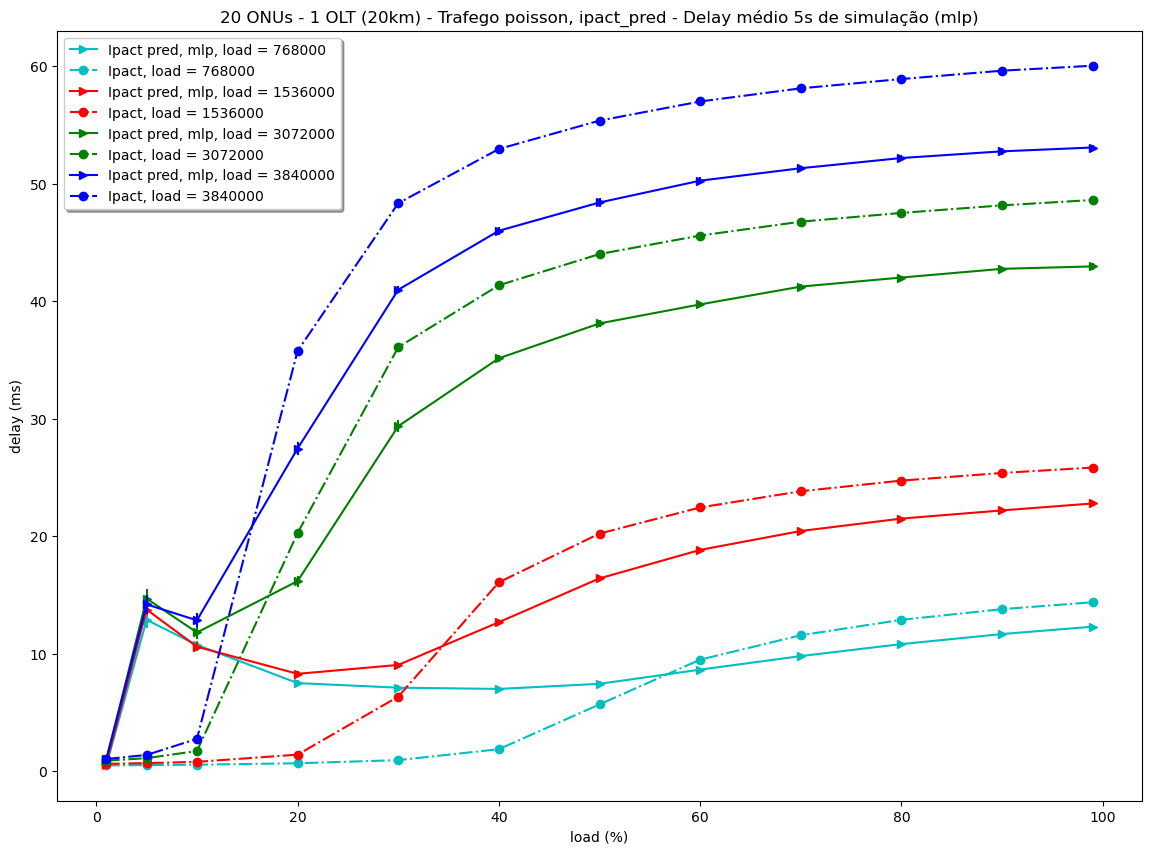

In [130]:
plt.clf()
plt.figure(figsize=(14, 10))
title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - Delay médio 5s de simulação ({})".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG, PRED_ALG)
plt.title(title)
plt.xlabel("load (%)")
plt.ylabel("delay (ms)")
plt.yscale('linear')
cmap = plt.get_cmap('gnuplot')
colors = ['c', 'r', 'g', 'b']
#plt.errorbar(loads, ipact_df.iloc[0].values,ipact_df.iloc[1].values,color="k", linestyle='None')
#plt.plot(loads, ipact_df.iloc[0], 'o-', color="k",label="IPACT")

i=0
for payload_size in PKT_SIZES:
    aux_df = pd.DataFrame(ipact_df_pr_medias[payload_size])
    aux_label = "Ipact pred, {}, load = {}".format(PRED_ALG, payload_size)
    media_delay = np.array(aux_df.iloc[:,0])
    aux_df = pd.DataFrame(ipact_df_pr_stds[payload_size])
    std_delay = np.array(aux_df.iloc[:,0])
    #print(std_delay)
    
    plt.plot(loads, media_delay, '->', color=colors[i], label=aux_label)
    plt.errorbar(loads, media_delay, std_delay, color=colors[i], linestyle='None')
    aux_df_b_ipact = pd.DataFrame(ipact_b_df_medias[payload_size])
    aux_label = "Ipact, load = {}".format(payload_size)
    media_delay = np.array(aux_df_b_ipact.iloc[:,0])
    plt.plot(loads, media_delay, '-o', color=colors[i], linestyle='-.', label=aux_label)
    i += 1
      
plt.legend(loc='best', shadow=True)
plt.savefig(title)
plt.show()


C:\Users\spiro\AppData\Local\Temp\ipykernel_12020\1915067046.py:27: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(loads, media_pl, '-o', color=colors[i], linestyle='-.', label=aux_label)


<Figure size 640x480 with 0 Axes>

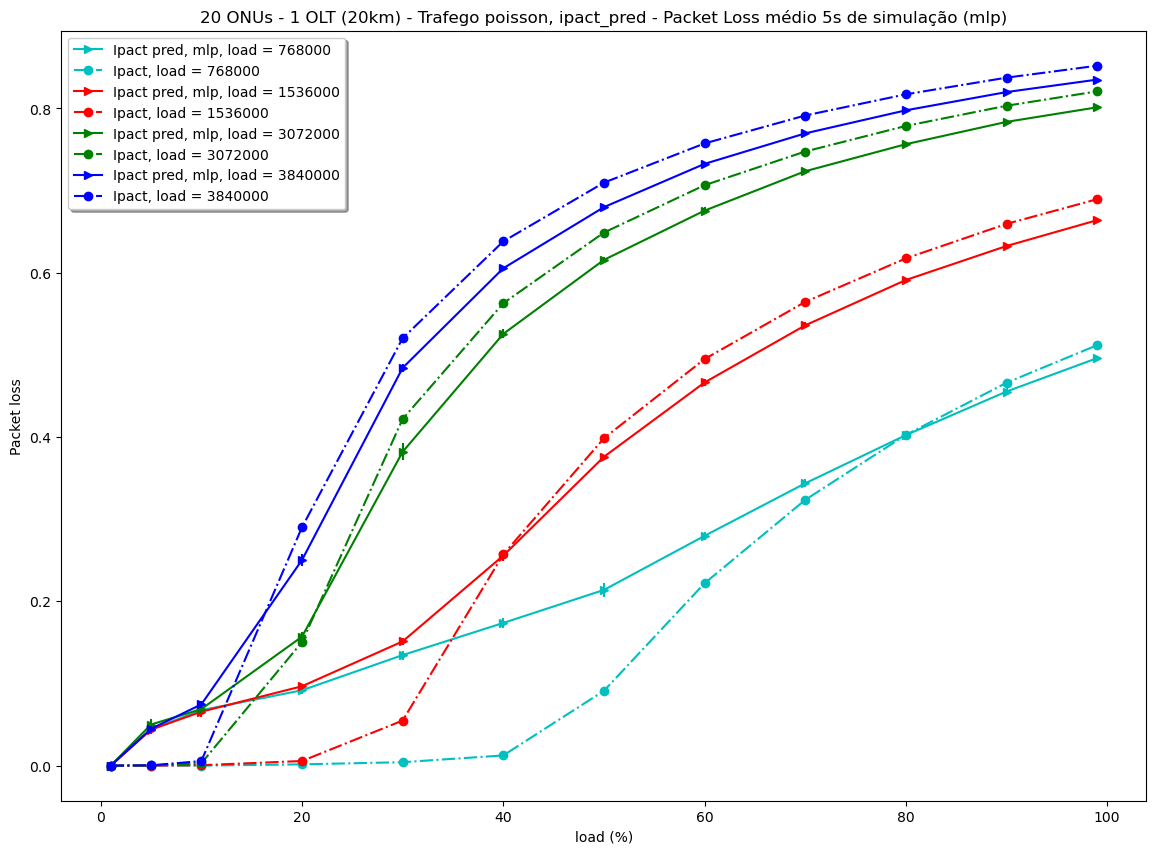

In [131]:
plt.clf()
plt.figure(figsize=(14, 10))
title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - Packet Loss médio 5s de simulação ({})".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG, PRED_ALG)
plt.title(title)
plt.xlabel("load (%)")
plt.ylabel("Packet loss")
plt.yscale('linear')
cmap = plt.get_cmap('gnuplot')
colors = ['c', 'r', 'g', 'b']
#plt.errorbar(loads, ipact_df.iloc[0].values,ipact_df.iloc[1].values,color="k", linestyle='None')
#plt.plot(loads, ipact_df.iloc[0], 'o-', color="k",label="IPACT")

i=0
for payload_size in PKT_SIZES:
    aux_df = pd.DataFrame(ipact_df_pr_pl_medias[payload_size])
    aux_label = "Ipact pred, {}, load = {}".format(PRED_ALG, payload_size)
    media_pl = np.array(aux_df.iloc[:,0])
    aux_df = pd.DataFrame(ipact_df_pr_pl_stds[payload_size])
    std_pl = np.array(aux_df.iloc[:,0])
    
    plt.plot(loads, media_pl, '->', color=colors[i], label=aux_label)
    plt.errorbar(loads, media_pl, std_pl, color=colors[i], linestyle='None')

    aux_df_b_ipact = pd.DataFrame(ipact_b_df_pl_medias[payload_size])
    aux_label = "Ipact, load = {}".format(payload_size)
    media_pl = np.array(aux_df_b_ipact.iloc[:,0])
    plt.plot(loads, media_pl, '-o', color=colors[i], linestyle='-.', label=aux_label)
    i += 1
      
plt.legend(loc='best', shadow=True)
plt.savefig(title)
plt.show()
